# 📌 Dataset Muestras Histopatológicas de Cancer de Mama

## Bibliotecas

In [ ]:
# ===============================
# 1. Módulos del sistema y gestión de archivos
# ===============================
import os
from os import listdir
from pathlib import Path
import glob
import zipfile

# ===============================
# 2. Módulos para manejo de datos
# ===============================
import pandas as pd
import numpy as np

# ===============================
# 3. Módulos para visualización
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.image import imread

# ===============================
# 4. Módulos para manipulación de imágenes
# ===============================
import cv2
from keras.preprocessing import image

# ===============================
# 5. Otros módulos
# ===============================
import requests
import random
import datetime

## Conjunto de Datos

In [ ]:
%%time
# URL del archivo
url = "https://www.inf.ufpr.br/vri/databases/BreaKHis_v1.tar.gz"
# Nombre del archivo de salida
file_name = "BreaKHis_v1.tar.gz"
# Descargar el archivo
response = requests.get(url, stream=True)
# Guardar el archivo en el sistema
with open(file_name, "wb") as file:
    for chunk in response.iter_content(chunk_size=1024):
        file.write(chunk)
print(f"Descarga completa: {file_name}")

Descarga completa: BreaKHis_v1.tar.gz
CPU times: user 33.3 s, sys: 7.99 s, total: 41.3 s
Wall time: 3min 39s


In [ ]:
!mkdir BreaKHis_v1
!tar -xvzf BreaKHis_v1.tar.gz -C BreaKHis_v1

Streaming output truncated to the last 5000 lines.
BreaKHis_v1/histology_slides/breast/malignant/SOB/mucinous_carcinoma/SOB_M_MC_14-13413/200X/SOB_M_MC-14-13413-200-007.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-5694/100X/SOB_M_DC-14-5694-100-012.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-14946/400X/SOB_M_DC-14-14946-400-003.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/lobular_carcinoma/SOB_M_LC_14-15570/400X/SOB_M_LC-14-15570-400-015.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-15572/40X/SOB_M_DC-14-15572-40-021.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-14946/40X/SOB_M_DC-14-14946-40-029.png
BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-16716/400X/SOB_M_DC-14-16716-400-030.png
BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549AB/400X/SOB_B_A-14-22549AB-400-021.png
B


# CARGA DEL CONJUNTO DE DATOS

In [ ]:
breast_img_paths = glob.glob('/content/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/**/*.png', recursive = True)

# Análisis Exploratorio de Datos (EDA)

In [ ]:
# Crear un DataFrame a partir de las rutas
df = pd.DataFrame(breast_img_paths , columns=["Image"])

# Expresión regular para extraer información de la ruta de la imagen
pattern = r"(?P<Procedure>SOB)_(?P<Type>B|M)_(?P<Subtype>A|F|PT|TA|DC|LC|MC|PC)-(?P<Year>\d+)-(?P<SlideID>[\w\d]+)-(?P<Magnification>\d+)-(?P<ImageNumber>\d+)\.png"

# Aplicar regex a la columna "Image" y extraer información en nuevas columnas
df_extracted = df["Image"].str.extract(pattern)

# Unir los datos extraídos al DataFrame original
df = pd.concat([df, df_extracted], axis=1)

df['label_int'] = df['Type'].map({'B': 0, 'M': 1})

df['label'] = df['Type'].map({'B': 'benign', 'M': 'malignant'})

# Diccionario de mapeo de Subtype a descripción
subtype_descriptions = {
    "A": "Adenosis (B)",
    "F": "Fibroadenoma (B)",
    "TA": "Tubular Adenoma (B)",
    "PT": "Phyllodes Tumor (B)",
    "DC": "Ductal Carcinoma (M)",
    "LC": "Lobular Carcinoma (M)",
    "MC": "Mucinous Carcinoma (M)",
    "PC": "Papillary Carcinoma (M)"
}
# Crear nueva columna con la descripción del Subtype
df["Subtype_Description"] = df["Subtype"].map(subtype_descriptions)
# Mostrar el DataFrame con las nuevas columnas
df.head()


,Image,Procedure,Type,Subtype,Year,SlideID,Magnification,ImageNumber,label_int,label,Subtype_Description
0,/content/BreaKHis_v1/BreaKHis_v1/histology_sli...,SOB,M,MC,14,13413,40,017,1,malignant,Mucinous Carcinoma (M)
1,/content/BreaKHis_v1/BreaKHis_v1/histology_sli...,SOB,M,MC,14,13413,40,022,1,malignant,Mucinous Carcinoma (M)
2,/content/BreaKHis_v1/BreaKHis_v1/histology_sli...,SOB,M,MC,14,13413,40,019,1,malignant,Mucinous Carcinoma (M)
3,/content/BreaKHis_v1/BreaKHis_v1/histology_sli...,SOB,M,MC,14,13413,40,009,1,malignant,Mucinous Carcinoma (M)
4,/content/BreaKHis_v1/BreaKHis_v1/histology_sli...,SOB,M,MC,14,13413,40,011,1,malignant,Mucinous Carcinoma (M)


In [ ]:
# Crear la tabla pivote
df_pivot = df.pivot_table(
    values="Image",
    index="Magnification",
    columns="label",
    aggfunc="count",
    fill_value=0
)

# Agregar subtotal por fila (Total por Magnification)
df_pivot["Total"] = df_pivot.sum(axis=1)

# Agregar subtotal por columna (Total por Type)
df_pivot.loc["Total"] = df_pivot.sum(axis=0)
df_pivot

label,benign,malignant,Total
Magnification,,,
100,644,1437,2081
200,623,1390,2013
40,625,1370,1995
400,588,1232,1820
Total,2480,5429,7909


In [ ]:
# Contar ocurrencias de cada tipo (Type) y subtipo (Subtype)
type_counts = df["label"].value_counts()
subtype_counts = df["Subtype_Description"].value_counts()

# Calcular el porcentaje
type_percent = (type_counts / type_counts.sum()) * 100
subtype_percent = (subtype_counts / subtype_counts.sum()) * 100

# Convertir a DataFrame para mejor visualización
type_df = pd.DataFrame({'Conteo': type_counts, 'Porcentaje': type_percent})
subtype_df = pd.DataFrame({'Conteo': subtype_counts, 'Porcentaje': subtype_percent})

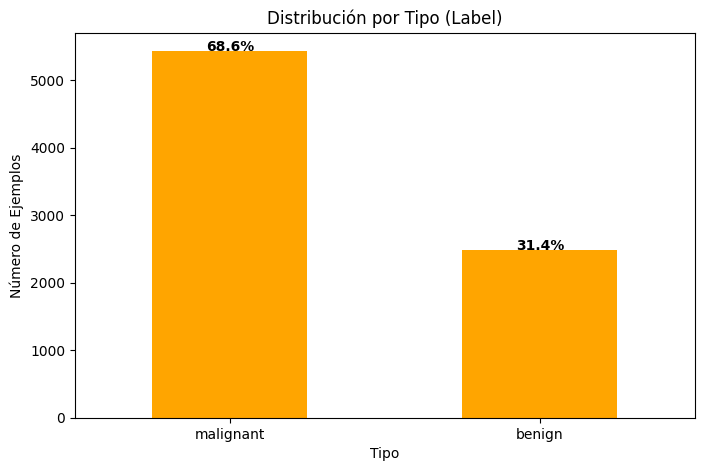

In [ ]:
# Crear gráfica de barras para "Type"
plt.figure(figsize=(8, 5))
type_counts.plot(kind='bar', rot=0, color="orange")
for i, v in enumerate(type_counts):
    plt.text(i, v + 2, f"{type_percent.iloc[i]:.1f}%", ha='center', fontsize=10, fontweight='bold')
plt.title("Distribución por Tipo (Label)")
plt.xlabel("Tipo")
plt.ylabel("Número de Ejemplos")
plt.show()

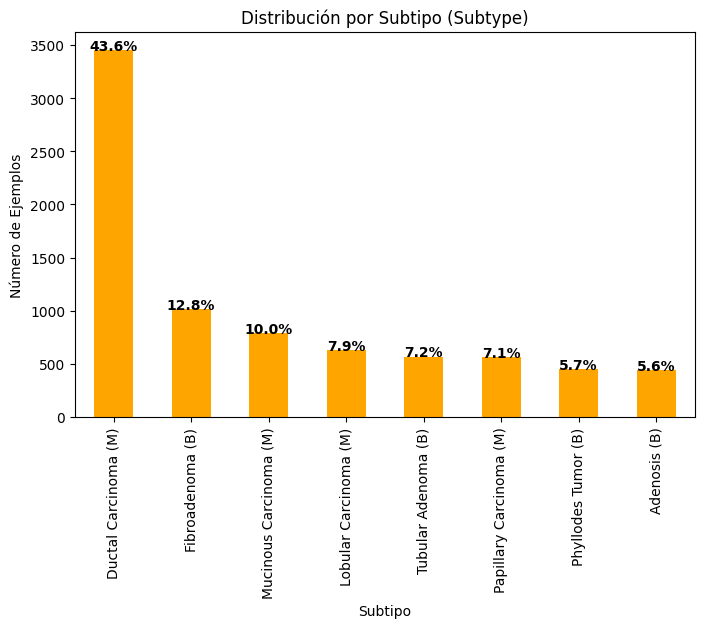

In [ ]:
# Crear gráfica de barras para "Subtype"
plt.figure(figsize=(8, 5))
subtype_counts.plot(kind='bar', rot=90, color="orange")
for i, v in enumerate(subtype_counts):
    plt.text(i, v + 1, f"{subtype_percent.iloc[i]:.1f}%", ha='center', fontsize=10, fontweight='bold')
plt.title("Distribución por Subtipo (Subtype)")
plt.xlabel("Subtipo")
plt.ylabel("Número de Ejemplos")
plt.show()

# Balanceo de clases

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# Función para cargar imágenes desde rutas
def load_images_from_paths(image_paths, target_size=(224, 224)):
    images = []
    for path in tqdm(image_paths):
        # Leer imagen
        img = cv2.imread(path)
        if img is None:
            print(f"No se pudo cargar la imagen: {path}")
            continue
        # Convertir de BGR a RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Redimensionar si es necesario
        img = cv2.resize(img, target_size)
        images.append(img)
    return np.array(images)

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir en train (65%) y temp (35%)
df_train, df_temp = train_test_split(df, test_size=0.35, stratify=df['label_int'], random_state=42)

# Dividir temp en val (20%) y test (15%)
df_val, df_test = train_test_split(df_temp, test_size=15/35, stratify=df_temp['label_int'], random_state=42)

# Analizar el desbalance
class_counts = df_train['label_int'].value_counts()
print("Distribución de clases original:", class_counts)

# Identificar la clase mayoritaria y minoritaria
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
num_majority = class_counts[majority_class]
num_minority = class_counts[minority_class]

Distribución de clases original: label_int
1    3528
0    1612
Name: count, dtype: int64


In [ ]:
# Cuántas imágenes sintéticas necesitamos generar
num_to_generate = num_majority - num_minority
int(num_to_generate)

1916

In [ ]:
# Filtrar el DataFrame para obtener solo las imágenes de la clase minoritaria
df_minority = df_train[df_train['label_int'] == minority_class]

# Cargar las imágenes de la clase minoritaria
minority_images = load_images_from_paths(df_minority['Image'].values)

100%|██████████| 1612/1612 [00:19<00:00, 84.84it/s]


In [ ]:
# Configurar el generador de data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,          # Rotación moderada (máx. 15 grados)
    width_shift_range=0.1,      # Desplazamiento horizontal (10%)
    height_shift_range=0.1,     # Desplazamiento vertical (10%)
    zoom_range=(0.9, 1.1),      # Zoom moderado (90% a 110% del tamaño original)
    horizontal_flip=True,       # Volteo horizontal permitido
    brightness_range=(0.9, 1.1),# Variación de brillo ligera
    fill_mode='nearest'         # Relleno con los valores de los píxeles más cercanos
)


In [ ]:
# Preparar para generar imágenes sintéticas
synthetic_images = []
batch_size = 32
batches_needed = int(np.ceil(num_to_generate / batch_size))

# Generar imágenes sintéticas
for i in range(batches_needed):
    # Seleccionar aleatoriamente imágenes de la clase minoritaria
    indices = np.random.randint(0, len(minority_images), min(batch_size, len(minority_images)))
    batch = minority_images[indices]

    # Generar imágenes aumentadas
    for x_batch in datagen.flow(batch, batch_size=batch_size, shuffle=False):
        synthetic_images.append(x_batch)
        if len(synthetic_images) * batch_size >= num_to_generate:
            break
        break

# Convertir a un solo array y limitar al número necesario
synthetic_images_array = np.vstack(synthetic_images)[:num_to_generate]


In [ ]:
# Crear un DataFrame con las nuevas imágenes sintéticas
# Pero primero necesitamos guardarlas en disco

# Crear directorio para imágenes sintéticas si no existe
synthetic_dir = "synthetic_images"
os.makedirs(synthetic_dir, exist_ok=True)

# Guardar imágenes sintéticas y crear lista de rutas
synthetic_paths = []
for i, img in enumerate(synthetic_images_array):
    path = os.path.join(synthetic_dir, f"synthetic_{i}.jpg")
    # Convertir a BGR para guardar con OpenCV
    cv2.imwrite(path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    synthetic_paths.append(path)

# Crear DataFrame con las imágenes sintéticas
df_synthetic = pd.DataFrame({
    'Image': synthetic_paths,
    'label_int': minority_class,
    'label': 'benign',
    'Type': 'B'
})

# Combinar con el DataFrame original
df_train_balanced = pd.concat([df_train, df_synthetic], ignore_index=True)

print("Distribución de clases después del balanceo:", df_train_balanced['label_int'].value_counts())

Distribución de clases después del balanceo: label_int
0    3528
1    3528
Name: count, dtype: int64


In [ ]:
# Contar las clases en cada conjunto
train_counts = df_train_balanced['label_int'].value_counts(normalize=True)
val_counts = df_val['label_int'].value_counts(normalize=True)
test_counts = df_test['label_int'].value_counts(normalize=True)

# Mostrar la distribución de clases en porcentaje
print("Distribución de clases:")
print("\nTrain (Balanceado):\n", train_counts)
print("\nValidation:\n", val_counts)
print("\nTest:\n", test_counts)

total_size = len(df_train_balanced) + len(df_val) + len(df_test)

# Calcular las proporciones respecto al total
train_proportion = len(df_train_balanced) / total_size
val_proportion = len(df_val) / total_size
test_proportion = len(df_test) / total_size

# Crear un DataFrame con los resultados
df_distribution = pd.DataFrame({
    "Conjunto": ["Train (Balanceado)", "Validation", "Test"],
    "Tamaño": [len(df_train_balanced), len(df_val), len(df_test)],
    "Proporción (%)": [train_proportion * 100, val_proportion * 100, test_proportion * 100]
})
df_distribution

Distribución de clases:

Train (Balanceado):
 label_int
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation:
 label_int
1    0.686473
0    0.313527
Name: proportion, dtype: float64

Test:
 label_int
1    0.686605
0    0.313395
Name: proportion, dtype: float64


,Conjunto,Tamaño,Proporción (%)
0,Train (Balanceado),7056,71.816794
1,Validation,1582,16.101781
2,Test,1187,12.081425


In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

# Definir rutas principales
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Crear carpetas si no existen
for subset in [train_dir, val_dir, test_dir]:
    for class_name in ["benign", "malignant"]:
        os.makedirs(os.path.join(subset, class_name), exist_ok=True)


# Función para mover imágenes a sus carpetas correspondientes
def move_images(df, subset_dir):
    for _, row in df.iterrows():
        src_path = row["Image"]  # Ruta original de la imagen
        class_name = "benign" if row["label_int"] == 0 else "malignant"
        dest_path = os.path.join(subset_dir, class_name, os.path.basename(src_path))
        shutil.copy2(src_path, dest_path)  # Copiar la imagen

# Mover imágenes a cada conjunto
move_images(df_train_balanced, train_dir)
move_images(df_val, val_dir)
move_images(df_test, test_dir)


## Modelado

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# Definir rutas de los datasets
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Generadores de imágenes SIN Data Augmentation (solo normalización)
datagen = ImageDataGenerator(rescale=1./255)

# Cargar imágenes en batches desde las carpetas
batch_size = 32
img_size = (299, 299)  # Tamaño de InceptionV3

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False  # Importante para evaluar correctamente
)

Found 9390 images belonging to 2 classes.
Found 3024 images belonging to 2 classes.
Found 2652 images belonging to 2 classes.


El DataFrame de métricas ya existe

=== Iniciando iteración 1/1 ===



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 8, 8, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,852,385 (87.17 MB)

 Trainable params: 1,049,601 (4.00 MB)

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 137s 465ms/step - accuracy: 0.9830 - auc: 0.9988 - loss: 0.1263 - prc: 0.9989 - precision: 0.9829 - recall: 0.9845 - val_accuracy: 0.9805 - val_auc: 0.9979 - val_loss: 0.1302 - val_prc: 0.9985 - val_precision: 0.9839 - val_recall: 0.9823
Epoch 35/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 131s 447ms/step - accuracy: 0.9838 - auc: 0.9989 - loss: 0.1236 - prc: 0.9990 - precision: 0.9830 - recall: 0.9863 - val_accuracy: 0.9785 - val_auc: 0.9981 - val_loss: 0.1307 - val_prc: 0.9986 - val_precision: 0.9714 - val_recall: 0.9920
Epoch 36/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9860 - auc: 0.9990 - loss: 0.1197 - prc: 0.9991 - precision: 0.9849 - recall: 0.9884

294/294 ━━━━━━━━━━━━━━━━━━━━ 135s 459ms/step - accuracy: 0.9860 - auc: 0.9990 - loss: 0.1197 - prc: 0.9991 - precision: 0.9849 - recall: 0.9885 - val_accuracy: 0.9825 - val_auc: 0.9981 - val_loss: 0.1254 - val_prc: 0.9986 - val_precision: 0.9846 - val_recall: 0.9851
Epoch 37/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9889 - auc: 0.9992 - loss: 0.1151 - prc: 0.9993 - precision: 0.9881 - recall: 0.9910

294/294 ━━━━━━━━━━━━━━━━━━━━ 132s 448ms/step - accuracy: 0.9889 - auc: 0.9992 - loss: 0.1151 - prc: 0.9993 - precision: 0.9881 - recall: 0.9910 - val_accuracy: 0.9825 - val_auc: 0.9981 - val_loss: 0.1235 - val_prc: 0.9986 - val_precision: 0.9840 - val_recall: 0.9857
Epoch 38/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9844 - auc: 0.9990 - loss: 0.1209 - prc: 0.9991 - precision: 0.9828 - recall: 0.9875

294/294 ━━━━━━━━━━━━━━━━━━━━ 132s 449ms/step - accuracy: 0.9844 - auc: 0.9990 - loss: 0.1209 - prc: 0.9991 - precision: 0.9828 - recall: 0.9875 - val_accuracy: 0.9835 - val_auc: 0.9982 - val_loss: 0.1210 - val_prc: 0.9987 - val_precision: 0.9846 - val_recall: 0.9868
Epoch 39/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9834 - auc: 0.9988 - loss: 0.1207 - prc: 0.9989 - precision: 0.9829 - recall: 0.9854

294/294 ━━━━━━━━━━━━━━━━━━━━ 134s 457ms/step - accuracy: 0.9834 - auc: 0.9988 - loss: 0.1207 - prc: 0.9989 - precision: 0.9829 - recall: 0.9854 - val_accuracy: 0.9838 - val_auc: 0.9983 - val_loss: 0.1202 - val_prc: 0.9987 - val_precision: 0.9813 - val_recall: 0.9908
Epoch 40/40
294/294 ━━━━━━━━━━━━━━━━━━━━ 131s 446ms/step - accuracy: 0.9867 - auc: 0.9990 - loss: 0.1166 - prc: 0.9990 - precision: 0.9846 - recall: 0.9901 - val_accuracy: 0.9812 - val_auc: 0.9984 - val_loss: 0.1207 - val_prc: 0.9989 - val_precision: 0.9742 - val_recall: 0.9937


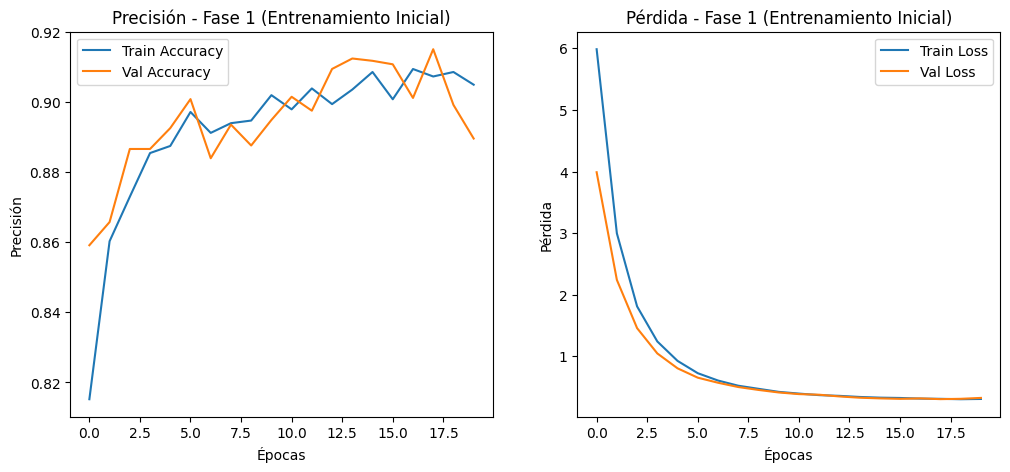

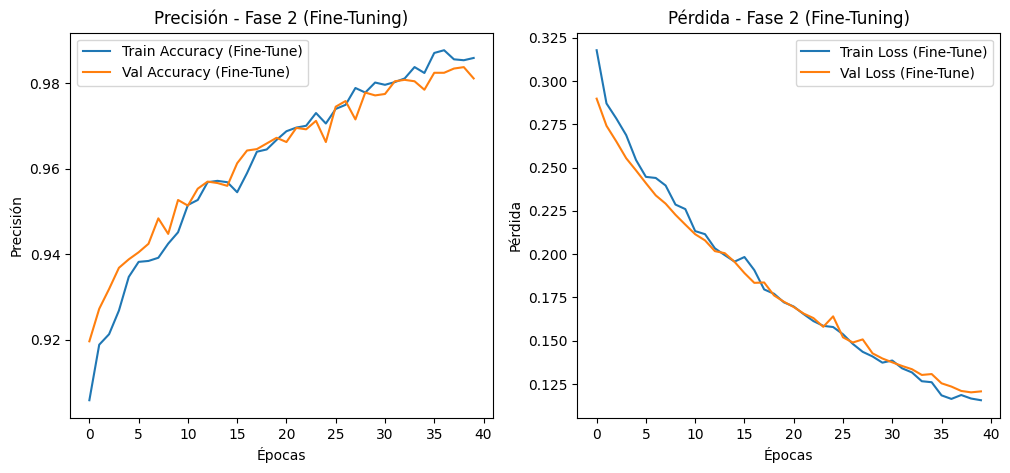

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2652/2652 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step


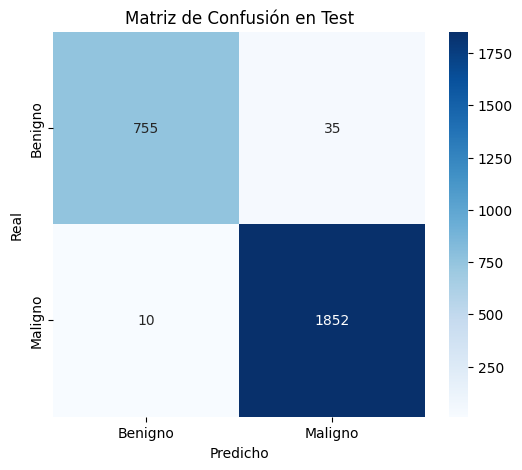


📊 Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.99      0.96      0.97       790
     Maligno       0.98      0.99      0.99      1862

    accuracy                           0.98      2652
   macro avg       0.98      0.98      0.98      2652
weighted avg       0.98      0.98      0.98      2652


--- Evaluación en datos de validación ---
95/95 ━━━━━━━━━━━━━━━━━━━━ 34s 361ms/step - accuracy: 0.9811 - auc: 0.9978 - loss: 0.1271 - prc: 0.9983 - precision: 0.9754 - recall: 0.9916
Nombres de métricas: ['loss', 'compile_metrics']
Resultados completos: [0.12016154825687408, 0.9837962985038757, 0.9812925457954407, 0.9908414483070374, 0.9982659816741943, 0.9987228512763977]

--- Evaluación en datos de entrenamiento ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 323ms/step - accuracy: 0.9958 - auc: 0.9999 - loss: 0.0934 - prc: 0.9999 - precision: 0.9938 - recall: 0.9977
2652/2652 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9681 - auc: 0.7013 - 

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from datetime import datetime


n_iteraciones = 1
# Crear DataFrame para almacenar métricas finales de cada iteración
columnas = ['iteracion', 'fase1_epochs', 'fase2_epochs',
            'accuracy', 'val_accuracy', 'precision', 'val_precision',
            'recall', 'val_recall', 'auc', 'val_auc', 'prc', 'val_prc',
            'loss', 'val_loss', 'timestamp']

# Verificar si el DataFrame existe
try:
    # Intentar acceder al DataFrame para ver si existe
    metricas_df.head()
    print("El DataFrame de métricas ya existe")
except NameError:
    # Si no existe, crearlo
    print("Creando nuevo DataFrame de métricas")
    metricas_df = pd.DataFrame(columns=columnas)

# Crear directorio para guardar modelos si no existe
os.makedirs('modelos_guardados', exist_ok=True)

# Ejecutar n iteraciones de entrenamiento
for iteracion in range(1, n_iteraciones + 1):
    print(f"\n=== Iniciando iteración {iteracion}/{n_iteraciones} ===\n")

    # Timestamp para identificar los modelos guardados
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Cargar modelo InceptionV3 sin la capa de clasificación
    base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(299, 299, 3))

    # Congelar capas del modelo base
    base_model.trainable = False

    # Crear modelo de Transfer Learning
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),  # Reduce dimensiones
        layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.Dropout(0.6),  # Regularización
        layers.Dense(1, activation='sigmoid')  # Capa final binaria
    ])

    # Compilar modelo con métricas completas para clasificación binaria
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(name='prc', curve='PR'),  # Precision-Recall curve
        ]
    )

    # Mostrar estructura del modelo solo en la primera iteración
    if iteracion == 1:
        model.summary()

    # Callbacks: Guardado de mejor modelo y Early Stopping
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        f"modelos_guardados/best_model_inception_iter{iteracion}_{timestamp}.h5",
        save_best_only=True
    )
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    # Entrenar modelo (Fase 1: solo capas superiores)
    print("\n--- Fase 1: Entrenamiento de capas superiores ---\n")
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=20,
        callbacks=[checkpoint_cb, early_stopping_cb]
    )

    # Guardar número de épocas realmente ejecutadas en la fase 1
    fase1_epochs = len(history.history['loss'])

    # Descongelar las últimas 20 capas de InceptionV3 para Fine-Tuning
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    # Compilar de nuevo con tasa de aprendizaje más baja
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.AUC(name='prc', curve='PR')
        ]
    )

    # Entrenar modelo (Fase 2: Fine-Tuning)
    print("\n--- Fase 2: Fine-Tuning ---\n")
    history_fine = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=40,
        callbacks=[checkpoint_cb, early_stopping_cb]
    )

    # 🔹 Gráfico de la Fase 1: Entrenamiento inicial
    plt.figure(figsize=(12, 5))

    # Precisión (Fase 1)
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.legend()
    plt.title("Precisión - Fase 1 (Entrenamiento Inicial)")
    plt.xlabel("Épocas")
    plt.ylabel("Precisión")

    # Pérdida (Fase 1)
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Pérdida - Fase 1 (Entrenamiento Inicial)")
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")

    plt.show()

    # 🔹 Gráfico de la Fase 2: Fine-Tuning
    plt.figure(figsize=(12, 5))

    # Precisión (Fine-Tuning)
    plt.subplot(1, 2, 1)
    plt.plot(history_fine.history["accuracy"], label="Train Accuracy (Fine-Tune)")
    plt.plot(history_fine.history["val_accuracy"], label="Val Accuracy (Fine-Tune)")
    plt.legend()
    plt.title("Precisión - Fase 2 (Fine-Tuning)")
    plt.xlabel("Épocas")
    plt.ylabel("Precisión")

    # Pérdida (Fine-Tuning)
    plt.subplot(1, 2, 2)
    plt.plot(history_fine.history["loss"], label="Train Loss (Fine-Tune)")
    plt.plot(history_fine.history["val_loss"], label="Val Loss (Fine-Tune)")
    plt.legend()
    plt.title("Pérdida - Fase 2 (Fine-Tuning)")
    plt.xlabel("Épocas")
    plt.ylabel("Pérdida")

    plt.show()
    # Guardar número de épocas realmente ejecutadas en la fase 2
    fase2_epochs = len(history_fine.history['loss'])

    # Obtener predicciones en test
    y_pred_probs = model.predict(test_generator)  # Probabilidades
    y_pred = (y_pred_probs > 0.5).astype(int)  # Convertir a 0 o 1

    # Obtener etiquetas verdaderas
    y_true = test_generator.classes

    # Crear matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Graficar la matriz de confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Benigno", "Maligno"], yticklabels=["Benigno", "Maligno"])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión en Test")
    plt.show()

    # Mostrar métricas de clasificación
    print("\n📊 Reporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=["Benigno", "Maligno"]))

    # Evaluar el modelo en datos de validación para obtener métricas finales
    print("\n--- Evaluación en datos de validación ---")
    val_results = model.evaluate(val_generator, verbose=1)
    val_metrics_dict = {}

    # Imprimir todos los nombres de métricas disponibles
    print("Nombres de métricas:", model.metrics_names)
    print("Resultados completos:", val_results)

    # Asegurar que hay correspondencia entre nombres y resultados
    if len(model.metrics_names) == len(val_results):
        for i, metric_name in enumerate(model.metrics_names):
            val_metrics_dict[metric_name] = val_results[i]
            print(f"Validation {metric_name}: {val_results[i]:.4f}")
    else:
        # Si hay un problema de correspondencia, extraer las métricas de la salida
        val_metrics_dict = {
            "loss": val_results[0],
            "accuracy": val_results[1] if len(val_results) > 1 else None,
            "precision": val_results[2] if len(val_results) > 2 else None,
            "recall": val_results[3] if len(val_results) > 3 else None,
            "auc": val_results[4] if len(val_results) > 4 else None,
            "prc": val_results[5] if len(val_results) > 5 else None
        }

    # Similar para los datos de entrenamiento
    print("\n--- Evaluación en datos de entrenamiento ---")
    train_results = model.evaluate(train_generator, steps=min(30, len(train_generator)), verbose=1)
    train_metrics_dict = {}

    if len(model.metrics_names) == len(train_results):
        for i, metric_name in enumerate(model.metrics_names):
            train_metrics_dict[metric_name] = train_results[i]
            print(f"Training {metric_name}: {train_results[i]:.4f}")
    else:
        # Si hay un problema de correspondencia
        train_metrics_dict = {
            "loss": train_results[0],
            "accuracy": train_results[1] if len(train_results) > 1 else None,
            "precision": train_results[2] if len(train_results) > 2 else None,
            "recall": train_results[3] if len(train_results) > 3 else None,
            "auc": train_results[4] if len(train_results) > 4 else None,
            "prc": train_results[5] if len(train_results) > 5 else None
        }

    # Guardar métricas finales de esta iteración
    nueva_fila = {
        'iteracion': iteracion,
        'fase1_epochs': fase1_epochs,
        'fase2_epochs': fase2_epochs,
        'accuracy': train_metrics_dict['accuracy'],
        'val_accuracy': val_metrics_dict['accuracy'],
        'precision': train_metrics_dict['precision'],
        'val_precision': val_metrics_dict['precision'],
        'recall': train_metrics_dict['recall'],
        'val_recall': val_metrics_dict['recall'],
        'auc': train_metrics_dict['auc'],
        'val_auc': val_metrics_dict['auc'],
        'prc': train_metrics_dict['prc'],
        'val_prc': val_metrics_dict['prc'],
        'loss': train_metrics_dict['loss'],
        'val_loss': val_metrics_dict['loss'],
        'timestamp': timestamp
    }

    # Añadir la nueva fila al DataFrame
    metricas_df = pd.concat([metricas_df, pd.DataFrame([nueva_fila])], ignore_index=True)

    # Guardar CSV después de cada iteración
    metricas_df.to_csv('metricas_inception_finales.csv', index=False)

    # Evaluación en conjunto de test si se proporciona
    if test_generator is not None:
        test_generator.reset()  # Reiniciar el generador para asegurar consistencia
        test_results = model.evaluate(test_generator, verbose=1)

        # Crear diccionario de métricas manualmente extrayendo valores de los logs
        test_metrics_dict = {
            "loss": test_results[0],
            "accuracy": test_results[1],
            "precision": test_results[2],
            "recall": test_results[3],
            "auc": test_results[4],
            "prc": test_results[5]
        }

        print("\nMétricas de test:")
        for metric_name, value in test_metrics_dict.items():
            print(f"  {metric_name}: {value:.4f}")
        test_df = pd.DataFrame([{
            'iteracion': iteracion,
            'accuracy': test_metrics_dict['accuracy'],
            'precision': test_metrics_dict['precision'],
            'recall': test_metrics_dict['recall'],
            'auc': test_metrics_dict['auc'],
            'prc': test_metrics_dict['prc'],
            'loss': test_metrics_dict['loss'],
            'timestamp': timestamp
        }])

        # Crear o actualizar archivo de métricas de test
        test_file = 'metricas_inception_test.csv'
        if os.path.exists(test_file):
            test_metrics_df = pd.read_csv(test_file)
            test_metrics_df = pd.concat([test_metrics_df, test_df], ignore_index=True)
        else:
            test_metrics_df = test_df

        test_metrics_df.to_csv(test_file, index=False)
print("\n=== Entrenamiento completado ===")
print(f"Se realizaron {n_iteraciones} iteraciones")
print(f"Las métricas finales se guardaron en 'metricas_inception_finales.csv'")

## BACKCUP (COLAB a DRIVE)

In [ ]:
from google.colab import drive
# Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!zip -r /content/dataset_backup.zip /content/dataset > /dev/null 2>&1
!mv /content/dataset_backup.zip /content/drive/MyDrive/

In [ ]:
!zip -r /content/modelos_guardados.zip /content/modelos_guardados > /dev/null 2>&1
!mv /content/modelos_guardados.zip /content/drive/MyDrive/

## Mejor Modelo

In [ ]:
metricas_df

,iteracion,fase1_epochs,fase2_epochs,accuracy,val_accuracy,precision,val_precision,recall,val_recall,auc,val_auc,prc,val_prc,loss,val_loss,timestamp
0,1,20,30,0.995833,0.976190,0.998058,0.972363,0.994197,0.986835,0.999941,0.997403,0.999950,0.998118,0.110113,0.142256,20250319_164436
1,1,20,40,0.993750,0.983796,0.991786,0.981293,0.995876,0.990841,0.999835,0.998266,0.999844,0.998723,0.097479,0.120162,20250319_192727


In [ ]:
test_metrics_df

,iteracion,accuracy,precision,recall,auc,prc,loss,timestamp
0,1,0.977753,0.975726,0.993018,0.997082,0.998756,0.145961,20250319_164436
1,1,0.983032,0.981452,0.994629,0.998009,0.999154,0.122816,20250319_192727


In [ ]:
metrica_principal='auc'
secundaria='recall'

if metricas_df.empty:
    raise ValueError("El dataframe de métricas está vacío")

# Encontrar el mejor valor para la métrica principal
mejor_valor = metricas_df[metrica_principal].max()
mejores_filas = metricas_df[metricas_df[metrica_principal] == mejor_valor]

# Si hay empate, usar la métrica secundaria
if len(mejores_filas) > 1 and secundaria in mejores_filas.columns:
    mejor_fila = mejores_filas.loc[mejores_filas[secundaria].idxmax()]
else:
    mejor_fila = mejores_filas.iloc[0]

# Crear información del mejor modelo
mejor_modelo = {
    'iteracion': mejor_fila['iteracion'],
    'fase1_epochs': mejor_fila['fase1_epochs'],
    'fase2_epochs': mejor_fila['fase2_epochs'],
    'accuracy': mejor_fila['accuracy'],
    'val_accuracy': mejor_fila['val_accuracy'],
    'precision': mejor_fila['precision'],
    'val_precision': mejor_fila['val_precision'],
    'recall': mejor_fila['recall'],
    'val_recall': mejor_fila['val_recall'],
    'auc': mejor_fila['auc'],
    'val_auc': mejor_fila['val_auc'],
    'loss': mejor_fila['loss'],
    'val_loss': mejor_fila['val_loss'],
    'timestamp': mejor_fila['timestamp'] if 'timestamp' in mejor_fila else None
}

# Encontrar el archivo del modelo correspondiente
directorio = 'modelos_guardados'
if os.path.exists(directorio):
    # Si tenemos timestamp, lo usamos para una búsqueda más precisa
    if mejor_modelo['timestamp']:
        archivos_modelo = [f for f in os.listdir(directorio)
                            if f.startswith(f'best_model_inception_iter{int(mejor_fila["iteracion"])}_{mejor_modelo["timestamp"]}')]
    else:
        # Si no hay timestamp, buscamos por número de iteración
        archivos_modelo = [f for f in os.listdir(directorio)
                            if f.startswith(f'best_model_inception_iter{int(mejor_fila["iteracion"])}_')]

    if archivos_modelo:
        mejor_modelo['archivo'] = os.path.join(directorio, archivos_modelo[0])
    else:
        mejor_modelo['archivo'] = f"No se encontró el archivo para la iteración {int(mejor_fila['iteracion'])}"
else:
    mejor_modelo['archivo'] = "Directorio de modelos no encontrado"

# Imprimir información del mejor modelo
print(f"\n=== MEJOR MODELO ENCONTRADO ===")
print(f"Iteración: {mejor_modelo['iteracion']}")
print(f"Épocas fase 1: {mejor_modelo['fase1_epochs']}")
print(f"Épocas fase 2: {mejor_modelo['fase2_epochs']}")
print(f"Métrica principal ({metrica_principal}): {mejor_modelo[metrica_principal]:.4f}")
print(f"Métrica secundaria ({secundaria}): {mejor_modelo[secundaria]:.4f}")
print(f"Accuracy (train/val): {mejor_modelo['accuracy']:.4f}/{mejor_modelo['val_accuracy']:.4f}")
print(f"Precision (train/val): {mejor_modelo['precision']:.4f}/{mejor_modelo['val_precision']:.4f}")
print(f"Recall (train/val): {mejor_modelo['recall']:.4f}/{mejor_modelo['val_recall']:.4f}")
print(f"Loss (train/val): {mejor_modelo['loss']:.4f}/{mejor_modelo['val_loss']:.4f}")
print(f"Archivo del modelo: {mejor_modelo['archivo']}")


=== MEJOR MODELO ENCONTRADO ===
Iteración: 1
Épocas fase 1: 20
Épocas fase 2: 30
Métrica principal (auc): 0.9999
Métrica secundaria (recall): 0.9942
Accuracy (train/val): 0.9958/0.9762
Precision (train/val): 0.9981/0.9724
Recall (train/val): 0.9942/0.9868
Loss (train/val): 0.1101/0.1423
Archivo del modelo: modelos_guardados/best_model_inception_iter1_20250319_164436.h5


## GRAD-MAP

Para entender cómo la red neuronal toma sus decisiones en la clasificación de imágenes histopatológicas de cáncer de mama, se utilizó la técnica **Grad-CAM** (Gradient-weighted Class Activation Mapping). Grad-CAM permite visualizar qué regiones de una imagen activaron más las capas profundas de la red para hacer una predicción, resaltando las áreas de mayor importancia mediante un mapa de calor.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import os
import matplotlib.gridspec as gridspec
import random

In [ ]:

# Función para generar Grad-CAM
def make_gradcam_heatmap(img_array, model):
    # Modelo para obtener salida de capa convolucional
    grad_model_conv = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:
        # Obtener activación de última capa convolucional
        conv_output = grad_model_conv(img_array)
        tape.watch(conv_output)

        # Pasar por el resto del modelo
        x = conv_output
        for layer in model.layers:
            if isinstance(layer, tf.keras.models.Model):
                continue
            x = layer(x)

        preds = x
        class_channel = preds[:, 0]  # Para clasificación binaria

    # Calcular gradientes
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Generar mapa de calor
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizar
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# Función para procesar una imagen y obtener resultados de Grad-CAM
def process_image(img_path, true_class_label):
    # Cargar y preprocesar imagen
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Hacer predicción
    preds = model.predict(img_array, verbose=0)
    pred_prob = float(preds[0][0])
    pred_class = 1 if pred_prob > 0.5 else 0

    # Generar Grad-CAM
    heatmap = make_gradcam_heatmap(img_array, model)

    # Redimensionar heatmap para coincidir con la imagen
    heatmap_resized = cv2.resize(heatmap, (299, 299))

    # Convertir a RGB para matplotlib
    img_rgb = np.array(img)

    # Aplicar colormap tipo "jet" al heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Crear superposición
    superimposed = np.uint8(0.6 * img_rgb + 0.4 * heatmap_colored)

    return {
        'original': img_rgb,
        'superimposed': superimposed,
        'pred_class': pred_class,
        'pred_prob': pred_prob,
        'filename': os.path.basename(img_path),
        'true_class_label': true_class_label,
        'pred_class_label': 'Maligno' if pred_class == 1 else 'Benigno'
    }
# Crear una visualización simplificada mostrando solo la imagen original y la superpuesta
def create_simplified_visualization(samples):
    fig = plt.figure(figsize=(20, 12))


    # Crear layout con GridSpec
    gs = gridspec.GridSpec(len(samples)//4, 4, figure=fig)
    gs.update(wspace=0.35, hspace=0.45)

    for i, sample in enumerate(samples):
        row = i // 4
        col = i % 4

        # Crear subgrid para cada muestra
        sub_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[row, col],
                                                 wspace=0.1)

        # Imagen original
        ax1 = fig.add_subplot(sub_gs[0, 0])
        ax1.imshow(sample['original'])
        ax1.set_title("Original", fontsize=12)
        ax1.axis('off')

        # Superposición
        ax2 = fig.add_subplot(sub_gs[0, 1])
        ax2.imshow(sample['superimposed'])

        # Texto de predicción
        pred_correct = (sample['true_class_label'] == 'Maligno' and sample['pred_class'] == 1) or \
                       (sample['true_class_label'] == 'Benigno' and sample['pred_class'] == 0)

        color = 'green' if pred_correct else 'red'

        title = f"Predicción: {sample['pred_class_label']} ({sample['pred_prob']:.2f})\n"
        title += f"Verdadero: {sample['true_class_label']}"

        ax2.set_title(title, color=color, fontsize=10)
        ax2.axis('off')

        # Agregar texto del nombre de archivo
        plt.figtext(ax1.get_position().x0,
                   ax1.get_position().y0 - 0.02,
                   os.path.basename(sample['filename']),
                   fontsize=8)

    # Guardar figura
    plt.savefig(f"{output_dir}/grad_cam_visualization_simplified.png", dpi=150, bbox_inches='tight')
    return fig

# Obtener muestras de imágenes malignas y benignas
def get_samples(directory, class_label, num_samples=8):
    full_dir = os.path.join(test_dir, directory)
    all_files = [f for f in os.listdir(full_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar aleatoriamente si hay demasiadas
    if len(all_files) > num_samples:
        selected_files = random.sample(all_files, num_samples)
    else:
        selected_files = all_files

    results = []
    for f in selected_files:
        img_path = os.path.join(full_dir, f)
        result = process_image(img_path, class_label)
        results.append(result)

    return results



In [ ]:
# Cargar el modelo entrenado
model = load_model("/best_model_inception_iter1_20250319_164436.h5")

# Definir la ruta de las imágenes de prueba
# test_dir = os.path.join("dataset", "test")
test_dir = '/content/drive/MyDrive/dataset_backup/test'
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=1,
    class_mode="binary",
    shuffle=False
)

# Identificar clases y directorios
class_indices = test_generator.class_indices
labels = {v: k for k, v in class_indices.items()}

malignant_dir = 'malignant'
benign_dir = 'benign'

Found 2652 images belonging to 2 classes.


Generando visualización simplificada...


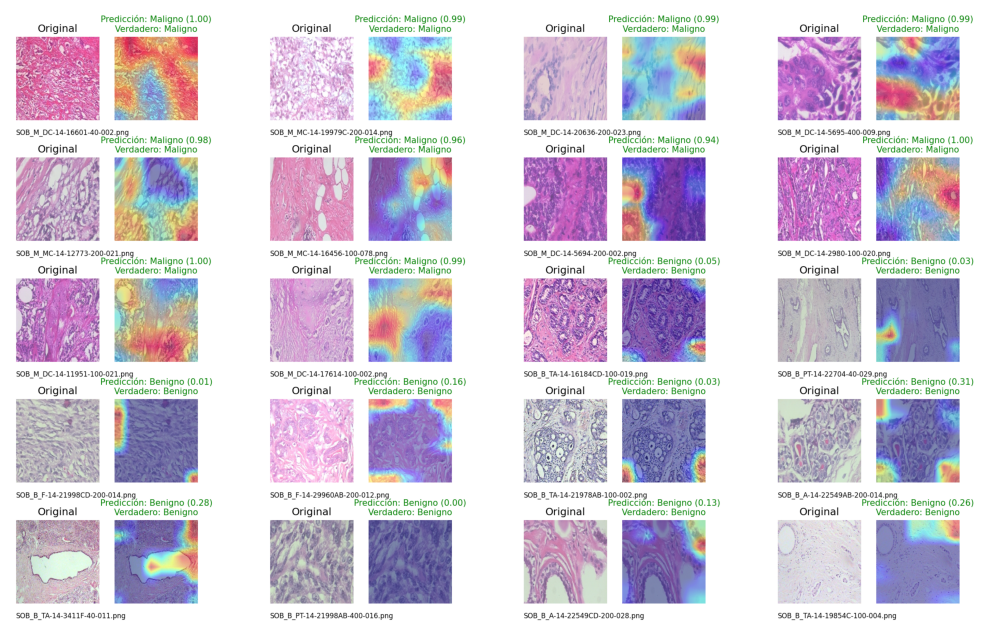

La visualización simplificada ha sido guardada en: grad_cam_results/grad_cam_visualization_simplified.png
¡Proceso completado!


In [ ]:
# Obtener la capa base InceptionV3
base_model = None
for layer in model.layers:
    if isinstance(layer, tf.keras.models.Model):
        base_model = layer
        break

if base_model is None:
    raise ValueError("No se pudo encontrar el modelo base InceptionV3")

# Obtener la última capa convolucional
last_conv_layer = base_model.get_layer("mixed10")

# Crear directorio para resultados
output_dir = "grad_cam_results"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Obtener muestras
num_samples_per_class = 10
malignant_samples = get_samples(malignant_dir, 'Maligno', num_samples_per_class)
benign_samples = get_samples(benign_dir, 'Benigno', num_samples_per_class)

# Combinar muestras
all_samples = malignant_samples + benign_samples

# Crear visualización simplificada
print("Generando visualización simplificada...")
viz_fig = create_simplified_visualization(all_samples)
plt.close(viz_fig)

# Mostrar visualización simplificada
plt.figure(figsize=(10, 8))
img = plt.imread(f"{output_dir}/grad_cam_visualization_simplified.png")
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"La visualización simplificada ha sido guardada en: {output_dir}/grad_cam_visualization_simplified.png")
print("¡Proceso completado!")